In [101]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score, ConfusionMatrixDisplay
from sklearn import metrics

In [102]:
_ROOT_DIR = './../../../'
X = pd.read_csv(_ROOT_DIR + './data/preprocessed/cell2cell_train.csv')
y = pd.read_csv(_ROOT_DIR + './data/preprocessed/cell2cell_train_churn.csv')

In [103]:
y = y.to_numpy().reshape(-1,)
y.shape

(49776,)

In [104]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [105]:
svm_clf = LinearSVC(random_state=42, class_weight='balanced')      # kernel: 적용할 커널 함수 설정
svm_clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [106]:
print("Train Accuarcy Score is :",svm_clf.score(X_train, y_train))
print("Test Accuarcy Score is  :", svm_clf.score(X_test, y_test))

Train Accuarcy Score is : 0.5882085074466945
Test Accuarcy Score is  : 0.5903246544519447


              precision    recall  f1-score   support

           0       0.78      0.60      0.68      8928
           1       0.36      0.58      0.44      3516

    accuracy                           0.59     12444
   macro avg       0.57      0.59      0.56     12444
weighted avg       0.66      0.59      0.61     12444



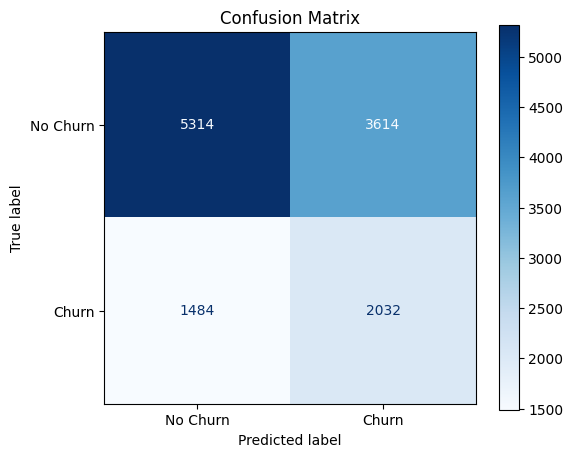

In [107]:
y_pred = svm_clf.predict(X_test)

print(classification_report(y_test, y_pred))

# Confusion Matrix 그래프 생성
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=plt.gca()) # ax=plt.gca()를 통해 현재 figure에 그림
plt.title('Confusion Matrix')
plt.show()

ROC-AUC Score: 0.6152429523407588


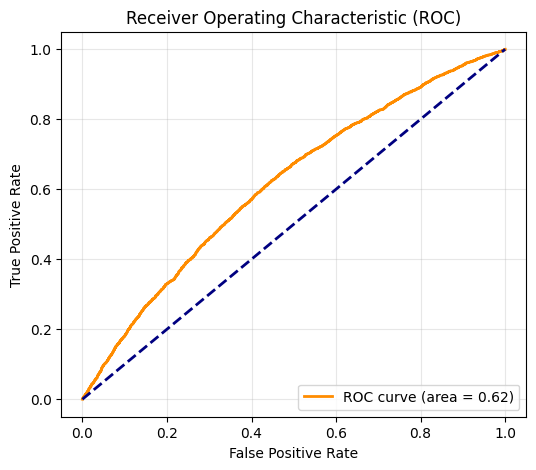

In [108]:
y_scores = svm_clf.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc_score(y_test, svm_clf.decision_function(X_test))}")

# ROC Curve 그래프 생성
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

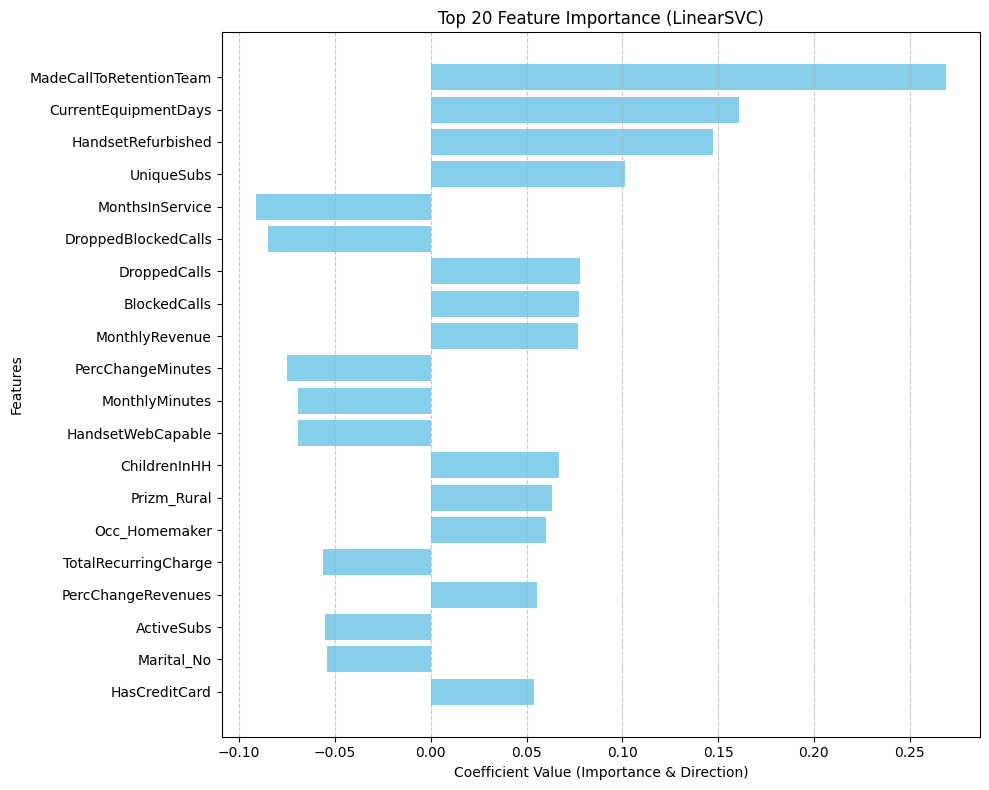

                    Feature  Coefficient
49  MadeCallToRetentionTeam     0.268703
26     CurrentEquipmentDays     0.160756
30       HandsetRefurbished     0.147550
22               UniqueSubs     0.101568
21          MonthsInService    -0.091126
18      DroppedBlockedCalls    -0.085061
8              DroppedCalls     0.078021
9              BlockedCalls     0.077254
0            MonthlyRevenue     0.076923
6         PercChangeMinutes    -0.075147
1            MonthlyMinutes    -0.069374
31        HandsetWebCapable    -0.069024
29             ChildrenInHH     0.067091
54              Prizm_Rural     0.063404
59            Occ_Homemaker     0.060408
2      TotalRecurringCharge    -0.056470
7        PercChangeRevenues     0.055445
23               ActiveSubs    -0.055030
51               Marital_No    -0.054256
39            HasCreditCard     0.053937


In [109]:
coefficients = svm_clf.coef_[0]
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients) # 절대값 기준 정렬용
}).sort_values(by='Abs_Coefficient', ascending=False)

# 상위 20개 피처 선택
top_20 = importance_df.head(20)

# 3. 그래프 그리기
plt.figure(figsize=(10, 8))

plt.barh(top_20['Feature'][::-1], top_20['Coefficient'][::-1], color='skyblue')
plt.xlabel('Coefficient Value (Importance & Direction)')
plt.ylabel('Features')
plt.title('Top 20 Feature Importance (LinearSVC)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. 수치로 확인
print(top_20[['Feature', 'Coefficient']])

# L1

In [110]:
svm_l1 = LinearSVC(penalty='l1', dual=False, C=0.01, class_weight='balanced', random_state=42, max_iter=10000)
svm_l1.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l1'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.01
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseud

In [111]:
print("L1 Train Accuarcy Score is :",svm_l1.score(X_train, y_train))
print("L1 Test Accuarcy Score is  :", svm_l1.score(X_test, y_test))

L1 Train Accuarcy Score is : 0.588985320904318
L1 Test Accuarcy Score is  : 0.5903246544519447


              precision    recall  f1-score   support

           0       0.78      0.60      0.68      8928
           1       0.36      0.58      0.44      3516

    accuracy                           0.59     12444
   macro avg       0.57      0.59      0.56     12444
weighted avg       0.66      0.59      0.61     12444



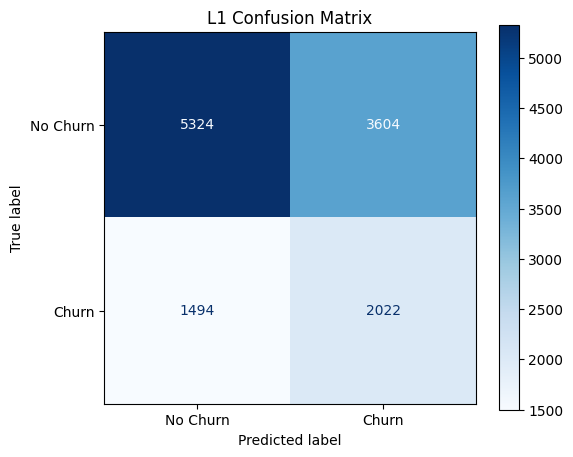

In [112]:
y_pred = svm_l1.predict(X_test)

print(classification_report(y_test, y_pred))

# Confusion Matrix 그래프 생성
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=plt.gca()) # ax=plt.gca()를 통해 현재 figure에 그림
plt.title('L1 Confusion Matrix')
plt.show()

ROC-AUC Score: 0.6156943259385665


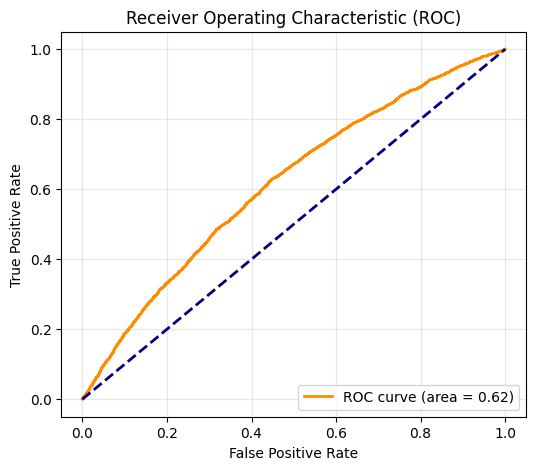

In [113]:
y_scores = svm_l1.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc_score(y_test, svm_l1.decision_function(X_test))}")

# ROC Curve 그래프 생성
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

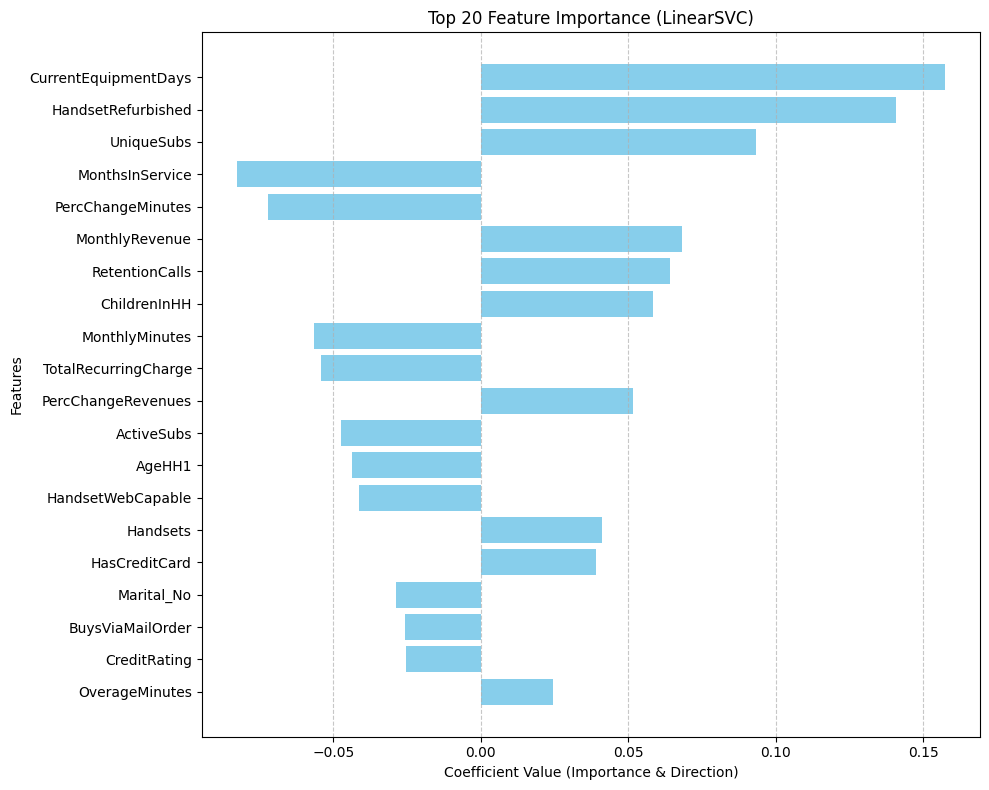

                 Feature  Coefficient
26  CurrentEquipmentDays     0.157254
30    HandsetRefurbished     0.140923
22            UniqueSubs     0.093221
21       MonthsInService    -0.082637
6      PercChangeMinutes    -0.072190
0         MonthlyRevenue     0.068266
40        RetentionCalls     0.064039
29          ChildrenInHH     0.058230
1         MonthlyMinutes    -0.056555
2   TotalRecurringCharge    -0.054333
7     PercChangeRevenues     0.051610
23            ActiveSubs    -0.047467
27                AgeHH1    -0.043799
31     HandsetWebCapable    -0.041251
24              Handsets     0.041076
39         HasCreditCard     0.039086
51            Marital_No    -0.028834
34      BuysViaMailOrder    -0.025824
50          CreditRating    -0.025295
4         OverageMinutes     0.024498


In [114]:
coefficients = svm_l1.coef_[0]
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients) # 절대값 기준 정렬용
}).sort_values(by='Abs_Coefficient', ascending=False)

# 상위 20개 피처 선택
top_20 = importance_df.head(20)

# 3. 그래프 그리기
plt.figure(figsize=(10, 8))

plt.barh(top_20['Feature'][::-1], top_20['Coefficient'][::-1], color='skyblue')
plt.xlabel('Coefficient Value (Importance & Direction)')
plt.ylabel('Features')
plt.title('Top 20 Feature Importance (LinearSVC)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 4. 수치로 확인
print(top_20[['Feature', 'Coefficient']])

In [115]:
dead_features = X.columns[svm_l1.coef_[0] == 0].tolist()

print(f"제외된 피처 개수: {len(dead_features)}")
print("제외된 피처 리스트:")
print(dead_features)

# 살아남은 피처 확인
alive_features = X.columns[svm_l1.coef_[0] != 0].tolist()
print(f"\n살아남은 피처 리스트: {alive_features}")

제외된 피처 개수: 19
제외된 피처 리스트:
['BlockedCalls', 'OffPeakCallsInOut', 'CallForwardingCalls', 'HandsetModels', 'TruckOwner', 'RVOwner', 'OptOutMailings', 'NonUSTravel', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'Marital_Yes', 'Prizm_Other', 'Occ_Clerical', 'Occ_Crafts', 'Occ_Homemaker', 'Occ_Other', 'Occ_Retired', 'Occ_Self', 'Occ_Student']

살아남은 피처 리스트: ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'DroppedBlockedCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUse

# optuna

In [116]:
import optuna

In [117]:
def objective(trial):
    c_param = trial.suggest_float('C', 0.0000001, 0.1, log=True)
    penalty_param = trial.suggest_categorical('penalty', ['l1', 'l2'])
    

    # LinearSVC 제약 조건 처리: 
    # penalty='l1'을 사용하려면 반드시 dual=False여야 함
    model = LinearSVC(
        C=c_param,
        penalty=penalty_param,
        dual=False,         # L1 규제 지원을 위해 False 고정
        max_iter=10000,
        class_weight='balanced',
        random_state=42
    )
    
    # 교차 검증(Cross Validation)으로 AUC 점수 계산
    # scoring='roc_auc'는 내부적으로 decision_function을 활용합니다.
    score = cross_val_score(
        model, X_train, y_train, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1
    ).mean()
    
    return score

In [118]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

[I 2026-02-23 16:50:14,039] A new study created in memory with name: no-name-e6baf050-9c9b-49ad-a8f2-93f70a29bc42
[I 2026-02-23 16:50:18,883] Trial 0 finished with value: 0.6143290861733515 and parameters: {'C': 0.026395870027688794, 'penalty': 'l2'}. Best is trial 0 with value: 0.6143290861733515.
[I 2026-02-23 16:50:22,865] Trial 1 finished with value: 0.6143033073250128 and parameters: {'C': 0.07572312481521082, 'penalty': 'l2'}. Best is trial 0 with value: 0.6143290861733515.
[I 2026-02-23 16:50:25,541] Trial 2 finished with value: 0.5 and parameters: {'C': 1.3108825429554813e-06, 'penalty': 'l1'}. Best is trial 0 with value: 0.6143290861733515.
[I 2026-02-23 16:50:28,384] Trial 3 finished with value: 0.6143863109441783 and parameters: {'C': 0.007544236307261406, 'penalty': 'l1'}. Best is trial 3 with value: 0.6143863109441783.
[I 2026-02-23 16:50:28,773] Trial 4 finished with value: 0.5999905381216648 and parameters: {'C': 1.0472073534578492e-05, 'penalty': 'l2'}. Best is trial 3 

In [119]:
best_params = study.best_params
best_params

{'C': 0.0005969162045991558, 'penalty': 'l2'}

In [120]:
final_model = LinearSVC(
    **best_params,
    class_weight='balanced',
    dual=False,
    random_state=42, 
    max_iter=20000  # 최종 학습이므로 반복 횟수를 넉넉히 줌
)

In [121]:
final_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.0005969162045991558
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",'balanced'
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneC

In [122]:
print("Optuna Train Accuarcy Score is :",final_model.score(X_train, y_train))
print("Optuna Test Accuarcy Score is  :", final_model.score(X_test, y_test))

Optuna Train Accuarcy Score is : 0.5879942140790743
Optuna Test Accuarcy Score is  : 0.5906460945033751


              precision    recall  f1-score   support

           0       0.78      0.60      0.68      8928
           1       0.36      0.58      0.44      3516

    accuracy                           0.59     12444
   macro avg       0.57      0.59      0.56     12444
weighted avg       0.66      0.59      0.61     12444



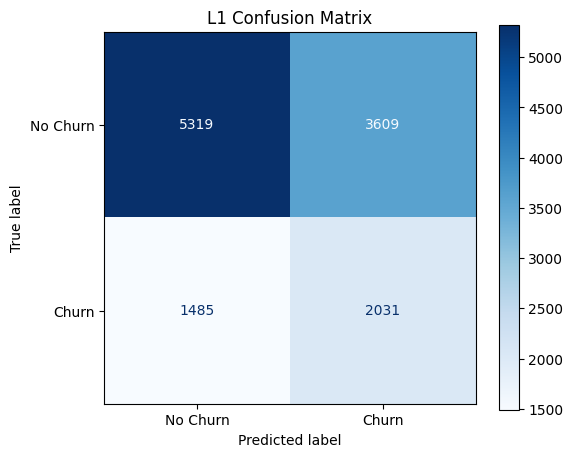

In [123]:
y_pred = final_model.predict(X_test)

print(classification_report(y_test, y_pred))

# Confusion Matrix 그래프 생성
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
disp.plot(cmap=plt.cm.Blues, ax=plt.gca()) # ax=plt.gca()를 통해 현재 figure에 그림
plt.title('L1 Confusion Matrix')
plt.show()

ROC-AUC Score: 0.6159002458296124


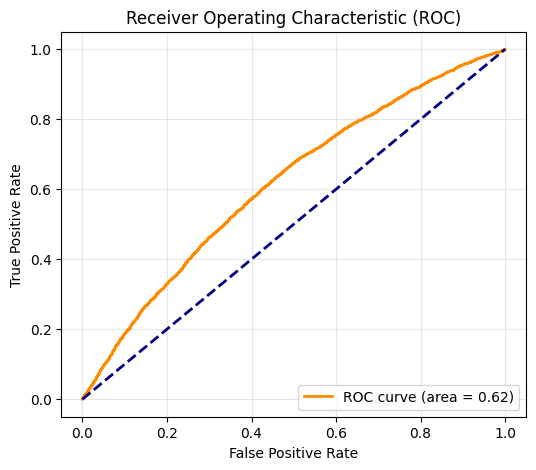

In [124]:
y_scores = final_model.decision_function(X_test)
fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc_score(y_test, final_model.decision_function(X_test))}")

# ROC Curve 그래프 생성
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [125]:
dead_features = X.columns[final_model.coef_[0] == 0].tolist()

print(f"제외된 피처 개수: {len(dead_features)}")
print("제외된 피처 리스트:")
print(dead_features)

# 살아남은 피처 확인
alive_features = X.columns[final_model.coef_[0] != 0].tolist()
print(f"\n살아남은 피처 리스트: {alive_features}")

제외된 피처 개수: 0
제외된 피처 리스트:
[]

살아남은 피처 리스트: ['MonthlyRevenue', 'MonthlyMinutes', 'TotalRecurringCharge', 'DirectorAssistedCalls', 'OverageMinutes', 'RoamingCalls', 'PercChangeMinutes', 'PercChangeRevenues', 'DroppedCalls', 'BlockedCalls', 'UnansweredCalls', 'CustomerCareCalls', 'ThreewayCalls', 'ReceivedCalls', 'OutboundCalls', 'InboundCalls', 'PeakCallsInOut', 'OffPeakCallsInOut', 'DroppedBlockedCalls', 'CallForwardingCalls', 'CallWaitingCalls', 'MonthsInService', 'UniqueSubs', 'ActiveSubs', 'Handsets', 'HandsetModels', 'CurrentEquipmentDays', 'AgeHH1', 'AgeHH2', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'RetentionCalls', 'RetentionOffersAccepted', 'NewCellphoneUser', 'NotNewCellphoneUser', 'ReferralsMadeBySubscriber', 'IncomeGroup', 'OwnsMotorcycle', 'AdjustmentsToCreditRating', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating',